<a href="https://colab.research.google.com/github/Jaydenkaleb/Introduction-to-AI/blob/main/Assignment%2015.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install shap

In [2]:
#Import teh neceassry library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import shap

import warnings
warnings.filterwarnings("ignore")

In [14]:
#load the dataset
df = pd.read_csv("loan_approval_dataset.csv")

In [15]:
#Explore teh dataset
df.head()
df.shape
df.info()
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB
Index(['loan_id

In [16]:
#clean the data
#check for null values

df.isnull().sum()

,0
loan_id,0
no_of_dependents,0
education,0
self_employed,0
income_annum,0
loan_amount,0
loan_term,0
cibil_score,0
residential_assets_value,0
commercial_assets_value,0


In [17]:
#check for duplicates
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
4264,False
4265,False
4266,False
4267,False


In [18]:
#ensure no spaces in the titles
df.columns = df.columns.str.strip().str.lower()

print(df.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')


In [20]:
#clean categorical values in teh education, self employed and loan status column
df['education'] = df['education'].astype(str).str.strip().str.lower()
df['self_employed'] = df['self_employed'].astype(str).str.strip().str.lower()
df['loan_status'] = df['loan_status'].astype(str).str.strip().str.lower()

In [21]:
#summary statistics
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


This analysis is to determien whether laon was aproved or rejected and why was it rejected based on teh features that are available in the dataset. therefore our target varaible is Loan_status

In [22]:
#print the loan status column to see how balanced the rejected and approvals
print(df['loan_status'].value_counts())

loan_status
approved    2656
rejected    1613
Name: count, dtype: int64


In [23]:
#percentage of target
print(df['loan_status'].value_counts(normalize=True) * 100)

loan_status
approved    62.215976
rejected    37.784024
Name: proportion, dtype: float64


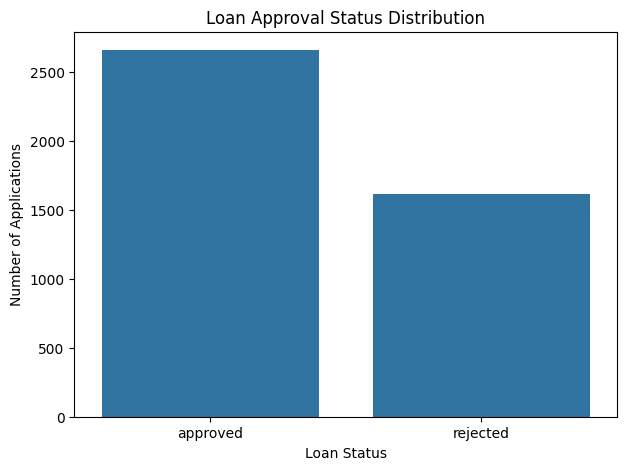

In [12]:
#visualize the approval and rejection
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='loan_status')

plt.title('Loan Approval Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Applications')

plt.show()

This shows a imlanced rate between the rejected and oapproved. Now i am going to perform an anysis to determein why the loans where rejected or pproved

In [13]:
#show all teh featured that are useful in this analysis. Note the the loan Id is not useful in determining the loan status therefore exclude it
numeric_columns = df.select_dtypes(include=np.number).columns

print(numeric_columns)

numeric_features = [
    'no_of_dependents',
    'income_annum',
    'loan_amount',
    'loan_term',
    'cibil_score',
    'residential_assets_value',
    'commercial_assets_value',
    'luxury_assets_value',
    'bank_asset_value'
]

Index(['loan_id', 'no_of_dependents', 'income_annum', 'loan_amount',
       'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value'],
      dtype='object')


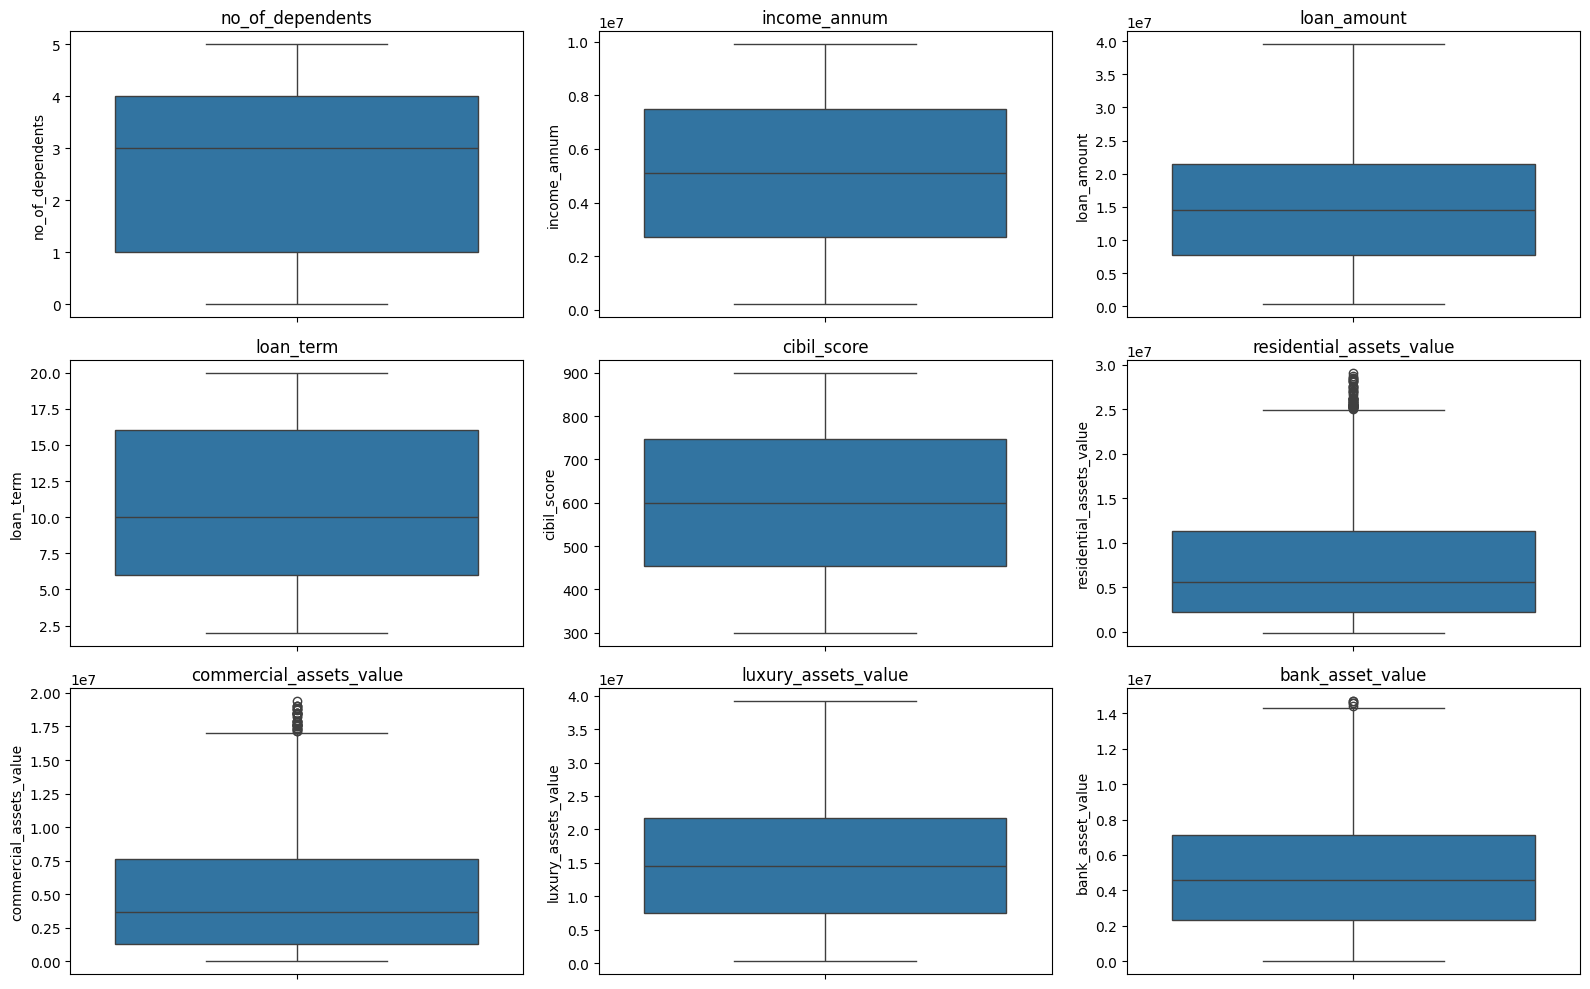

In [24]:
#Visualize teh outliers using box plots
plt.figure(figsize=(16, 10))

for i, column in enumerate(numeric_features, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()

Ressidentail asset value, commercial asset value and bank asset value have outliers. This can cause unfairness in determining if teh loan will be approved or not uin that the model can place too much relevance on teh partern for perople who have higher assets value in terms of commercial, residential and bank. this is becasue they might think that having those things will be a great colaterals that the loans will be repaid. But the model is to determine if given a balnced data, will that loan still be approved or rejected?

**Relationship Between Features and Loan Status**

We are determining the relation these features have with the target variable before the deployment of the model

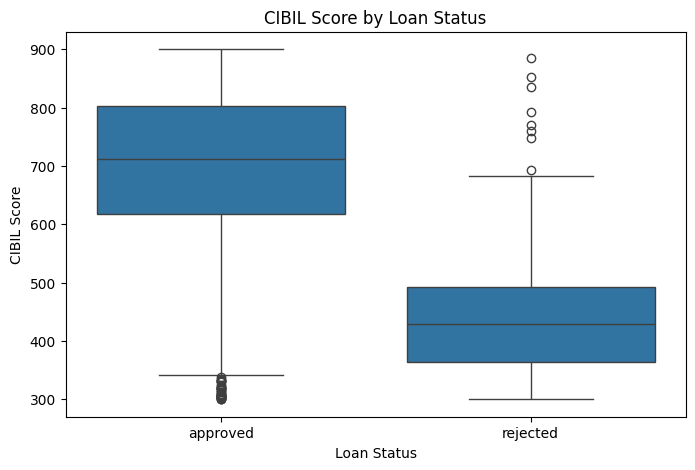

In [25]:
#CIBIL score versus loan status:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='loan_status',
    y='cibil_score'
)

plt.title('CIBIL Score by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('CIBIL Score')

plt.show()



> This shows that applicant who usually have haigh cibil score get aproved  an dthose with lower cibil score gets rejected most of teh time.



In [30]:
#convert the target variable to numeric data
df['loan_status'] = df['loan_status'].map({
    'approved': 1,
    'rejected': 0
})

In [31]:
df['loan_status'].value_counts()

,count
loan_status,
1,2656
0,1613


** feature Engineering**

In [28]:
#combinding all the assets into one to get teh total assets each applicant have.
df['total_assets'] = (
    df['residential_assets_value'] +
    df['commercial_assets_value'] +
    df['luxury_assets_value'] +
    df['bank_asset_value']
)

In [29]:
print(df.total_assets)

0       50700000
1       17000000
2       57700000
3       52700000
4       55000000
          ...   
4264     7400000
4265    20000000
4266    39000000
4267    28800000
4268    77300000
Name: total_assets, Length: 4269, dtype: int64


In [37]:
#dropping the loan id column
X = df.drop(
    columns=['loan_status', 'loan_id']
)

y = df['loan_status']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4269, 16)
y shape: (4269,)


In [46]:
#identifying the numerical and categorical
categorical_features = [
    'education',
    'self_employed'
]

numerical_features = [
    column for column in X.columns
    if column not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['education', 'self_employed']

Numerical features:
['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'total_assets', 'loan_to_income', 'assets_to_income', 'annual_loan_burden', 'income_plus_bank_assets']


**Model Building and Evaluation**

In [47]:
#split training and testing data and use stratify to balnace teh data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3415, 16)
Testing data: (854, 16)


In [48]:
#applying encoding technique
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

In [49]:
#Combine them
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numerical_features),
    ('categorical', categorical_pipeline, categorical_features)
])

In [50]:
#Train a Random Forest classifier
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)


In [53]:
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', random_forest)
])


In [52]:
#Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['no_of_dependents',
                                                   'income_annum',
                                                   'loan_amount', 'loan_term',
                                                   'cibil_score',
                                                   'residential_assets_value',
                                                   'commercial_assets_value',
                                                   'luxury_assets_value',
                                                   'bank_asset_value',
                                                   'total_assets',
                                                   'loan_to_income',
                                                   'assets_to_income',
                                                   'annual_loan_burden',
                                                   'income_plus_bank_assets']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['education',
                                                   'self_employed'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [56]:
#Make Predictions
y_pred = model.predict(X_test)

In [57]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[319   4]
 [  0 531]]


<Figure size 700x500 with 0 Axes>

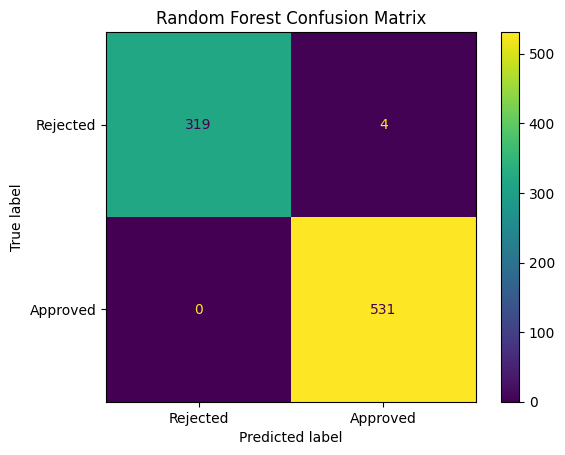

In [58]:
#confusion matrix visualization
plt.figure(figsize=(7, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Rejected', 'Approved']
).plot()

plt.title('Random Forest Confusion Matrix')

plt.show()

319 rejected loans were correctly predicted as Rejected
531 approved loans were correctly predicted as Approved
that means the model was able to correctly predict a total of 850

Also, 4 rejected loans were incorrectly predicted as Approved
and 0 approved loans were incorrectly predicted as Rejected

In [59]:
#classification report
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

              precision    recall  f1-score   support

    Rejected       1.00      0.99      0.99       323
    Approved       0.99      1.00      1.00       531

    accuracy                           1.00       854
   macro avg       1.00      0.99      1.00       854
weighted avg       1.00      1.00      1.00       854



Rejected = 1.00 meaning when the model predicted "Rejected," it was always correct.
Approved = 0.99 means 99% of the applications predicted as Approved were actually Approved.

Rejected = 0.99 means the model correctly identified about 99% of all actually rejected applications.
Approved = 1.00 means, the model identified all 531 actually approved applications.

In [60]:
#using teh accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100)

Accuracy: 0.9953161592505855
Accuracy percentage: 99.53161592505855


The Random Forest model achieved an accuracy of 99.53% on the test dataset, correctly classifying 850 out of 854 loan applications. Only four applications were misclassified as seen in teh confussion matrix.

In [74]:
#feature importance
X_train_transformed = model.named_steps[
    'preprocessor'
].transform(X_train)

In [75]:
feature_names = (
    numerical_features +
    list(
        model.named_steps[
            'preprocessor'
        ]
        .named_transformers_['categorical']
        .named_steps['encoder']
        .get_feature_names_out(categorical_features)
    )
)

In [77]:
importance = model.named_steps[
    'classifier'
].feature_importances_

In [78]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values(
    by='Importance',
    ascending=False
)

In [79]:
feature_importance

,Feature,Importance
4,cibil_score,0.790693
3,loan_term,0.043253
10,loan_to_income,0.041243
12,annual_loan_burden,0.025876
11,assets_to_income,0.014350
2,loan_amount,0.014094
5,residential_assets_value,0.009859
9,total_assets,0.009847
6,commercial_assets_value,0.008931
7,luxury_assets_value,0.008783


**Explainability and Fairness Analysis**

In [65]:
#SHAP Explainability
X_test_transformed = model.named_steps[
    'preprocessor'
].transform(X_test)

#Create SHAP Explainer
explainer = shap.TreeExplainer(
    model.named_steps['classifier']
)

In [66]:
#Calculate the SHAP value
shap_values = explainer.shap_values(
    X_test_transformed
)


In [73]:
print(type(shap_values))

if isinstance(shap_values, list):
    print(len(shap_values))
    print(shap_values[0].shape)
else:
    print(shap_values.shape)

<class 'numpy.ndarray'>
(854, 18, 2)


In [86]:
if isinstance(shap_values, list):
    shap_values_approved = shap_values[1]
else:
    shap_values_approved = shap_values[:, :, 1]

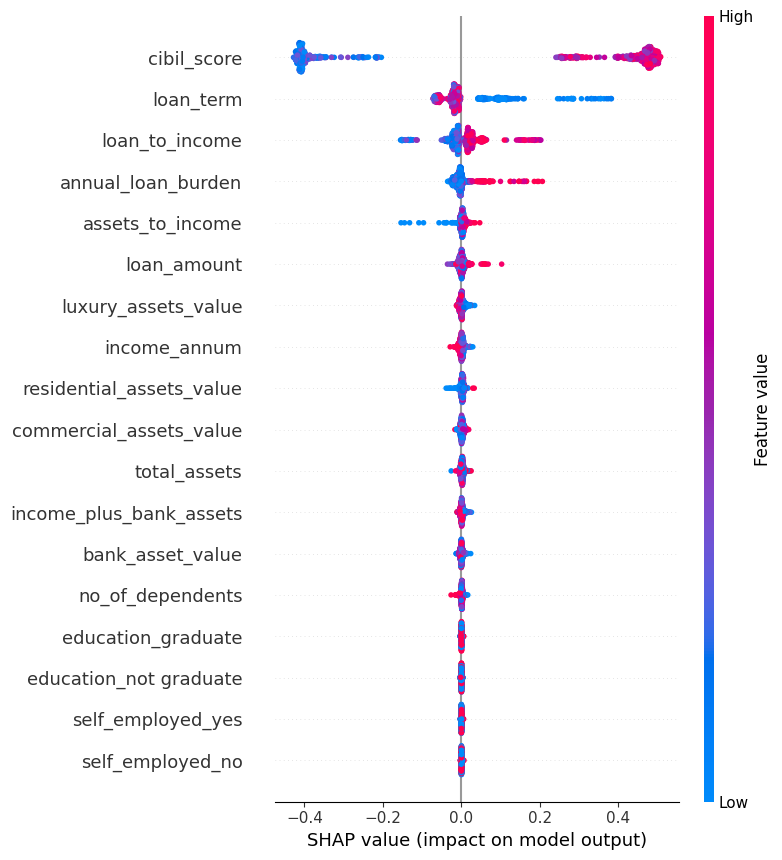

In [80]:
#plot to see whether high or low feature values push predictions toward approval
shap.summary_plot(
    shap_values_approved,
    X_test_transformed,
    feature_names=feature_names
)

High Cibil score pushes the  prediuction towards being approved and lower loan burden pushes teh prediction towards being approved.

**Assess fairness by comparing model performance**

In [82]:
#Fairness by Education
test_results = X_test.copy()

test_results['actual'] = y_test
test_results['predicted'] = y_pred

test_results['education'] = X_test['education'].values

In [85]:
#Check perfomance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

education_results = []

for group in test_results['education'].unique():

    group_data = test_results[
        test_results['education'] == group
    ]

    accuracy = accuracy_score(
        group_data['actual'],
        group_data['predicted']
    )

    precision = precision_score(
        group_data['actual'],
        group_data['predicted'],
        zero_division=0
    )

    recall = recall_score(
        group_data['actual'],
        group_data['predicted'],
        zero_division=0
    )

    f1 = f1_score(
        group_data['actual'],
        group_data['predicted'],
        zero_division=0
    )

    education_results.append({
        'Education': group,
        'Count': len(group_data),
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })


education_fairness = pd.DataFrame(education_results)

education_fairness


,Education,Count,Accuracy,Precision,Recall,F1 Score
0,not graduate,420,0.992857,0.988636,1.0,0.994286
1,graduate,434,0.997696,0.996310,1.0,0.998152


The fairness analysis compared the Random Forest model's performance between graduate and non-graduate applicants. The model achieved an accuracy of 99.29% for non-graduates and 99.77% for graduates. Precision was 98.86% for non-graduates and 99.63% for graduates, while recall was 100% for both groups. The F1-score was also very similar, at 99.43% for non-graduates and 99.82% for graduates. Overall, the results indicate that the model had very similar predictive performance across the two education groups in the test dataset.

